# **OKCupid Date-a-Scientist**

##### By Faatimah Majothi

### Introduction

In this project, we will be analysing data from OKCupid, a dating app that focuses on using multiple choice and short answers to match users. We will attempt to build, train, and evaluate a machine learning model that predicts a target aspect of user profiles based on the other features in the dataset.
The data in this project was provided by [Codecademy's OKCupid machine learning project page](https://www.codecademy.com/paths/data-science/tracks/dscp-machine-learning-portfolio-project/modules/dscp-okcupid-date-a-scientist/kanban_projects/okcupid-date-a-scientist-portfolio-project#skip-content-tasks).

### Project Scope

This project aims to:
1. Load and analyse the data of the profiles in **`profiles.csv`**
2. Clean and transform the data for training machine learning models
3. Implement machine learning algorithms to predict the smoker status of users based on features


Three models will be trained to predict users' smoker status based on profile features. We will train a decision tree classifier, a logistic regression model and a K-Nearest Neighbors (KNN) model. We will evaluate the models to determine which had the highest accuracy.

## **Section A:** Data Setup

To begin with, the libraries necessary for data handling, visualisation and machine learning processes are imported.

In [33]:
# Initialise Libraries

# Data Handling
import pandas as pd
import numpy as np

# Visualisation
from matplotlib import pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,\
confusion_matrix, classification_report, ConfusionMatrixDisplay

# Plot colour parameters
plt.rcParams['figure.facecolor'] = '#F5D9D7'
plt.rcParams['axes.facecolor'] = '#FFFFFF'

Next, the first few lines of the dataset are previewed to get an idea of the columns and a glimpse of the possible rows.

In [34]:
# Import data
profiles = pd.read_csv('profiles.zip')

# Preview
profiles.head(2)

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single


At first glance, it appears that the columns with the word 'essay' in them are free responses to questions. A look at the original dataset on excel sheds more light on the questions asked. Since the essay questions were open ended, we had to look at a few of the responses to infer the questions asked.

| Column   | Possible Question Asked                            |
|----------|----------------------------------------------------|
| essay0   | Decribing myself in a nutshell:                    |
| essay1   | What am I currently pursuing?                      |
| essay2   | What am I good at?                                 |
| essay3   | First thing people notice about me:                |
| essay4   | What is my favourite pastime?                      |
| essay5   | Six things I wouldn't want to live without:        |
| essay6   | What do I spend time thinking about?               |
| essay7   | I spend my friday nights doing:                    |
| essay8   | A private fact about me:                           |
| essay9   | What kind of person am I looking for?              |

Excluding these open-ended questions, we can then take a look at the summary statistics of the columns and display further information using `.describe()` and `.info()`

In [35]:
# Exclude essay columns
profile_essays = profiles[[col for col in profiles.columns if 'essay' in col]]
profiles_features = profiles.drop(profile_essays, axis=1)

# Summary statistics
print(profiles_features.describe())

# Column information
print(profile_essays.info())
profiles_features.info()

                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290     68.295281    20033.222534
std        9.452779      3.994803    97346.192104
min       18.000000      1.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max      110.000000     95.000000  1000000.000000
<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   essay0  54458 non-null  str  
 1   essay1  52374 non-null  str  
 2   essay2  50308 non-null  str  
 3   essay3  48470 non-null  str  
 4   essay4  49409 non-null  str  
 5   essay5  49096 non-null  str  
 6   essay6  46175 non-null  str  
 7   essay7  47495 non-null  str  
 8   essay8  40721 non-null  str  
 9   essay9  47343 non-null  str  
dtypes: str(10)
memory usage: 4.

Three of the columns, **`age`**, **`height`** and **`income`** appear to be both numerical and continuous while the rest are categorical. Many of the columns appear to have null values. We can find which ones with the following code.

In [36]:
# Find columns with nulls and print column names and null counts
null_counts = profiles_features.isnull().sum()
has_nulls = null_counts[null_counts > 0]
has_nulls

body_type     5296
diet         24395
drinks        2985
drugs        14080
education     6628
ethnicity     5680
height           3
job           8198
offspring    35561
pets         19921
religion     20226
sign         11056
smokes        5512
speaks          50
dtype: int64

It is clear that some columns have far more nulls than others, such as the **`diet`**, **`offspring`** and **`religion`** columns. This suggests that many people were uncomfortable answering them due to the sensitivity of the topics.

## **Section B:** Exploratory Data Analysis

Moving on to the EDA (Exploratory Data Analysis) step, we will be focusing on visualising aspects of the columns in `profiles_features`, excluding the essay questions. 
To begin with, we will take a look at the distributions of the numerical features in the `age`, `height` and `income` columns.

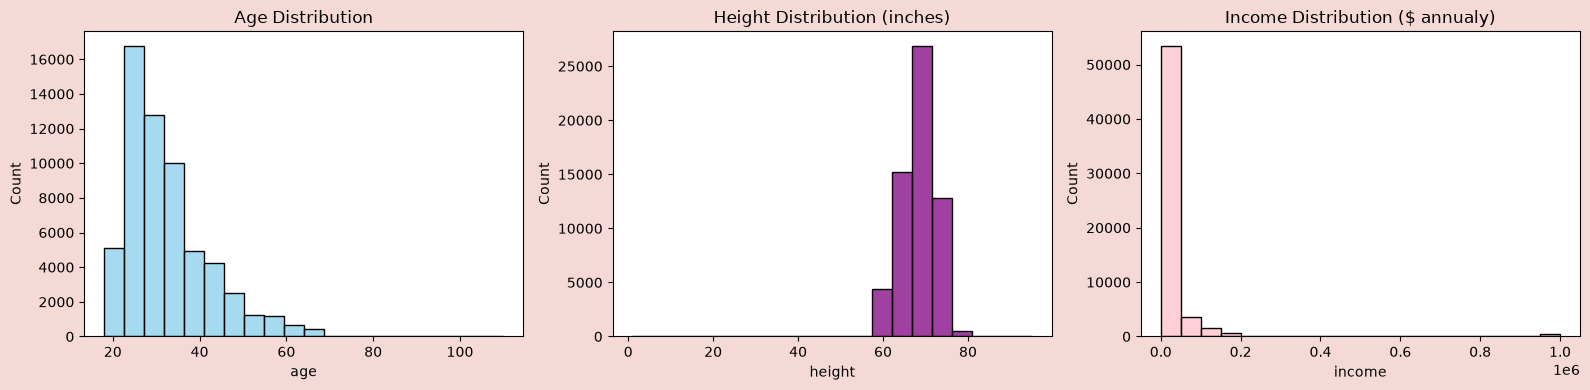

In [37]:
# Visualising the distributions of age, height and income in the dataset
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(profiles_features['age'], bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Age Distribution')

sns.histplot(profiles_features['height'], bins=20, color='purple', ax=ax[1])
ax[1].set_title('Height Distribution (inches)')

sns.histplot(profiles_features['income'], bins=20, color='pink', ax=ax[2])
ax[2].set_title('Income Distribution ($ annualy)')

plt.tight_layout()
plt.savefig('ageheightincomehist.png', bbox_inches='tight')
plt.show()
plt.close()

The range of the distribution of some of the features, such as the lowest `height` value and highest `age` value do not make sense. These may be errors or outliers in the data. As a reminder, the summary statistics of the three columns were as follows:

In [38]:
# Summary statistics
print(profiles_features.describe())

                age        height          income
count  59946.000000  59943.000000    59946.000000
mean      32.340290     68.295281    20033.222534
std        9.452779      3.994803    97346.192104
min       18.000000      1.000000       -1.000000
25%       26.000000     66.000000       -1.000000
50%       30.000000     68.000000       -1.000000
75%       37.000000     71.000000       -1.000000
max      110.000000     95.000000  1000000.000000


The minimum `height` value of 1 is clearly an **error or incorrect entry**, and the maximum `age` value of **110 is unlikely to be the real age** of a user on a dating app. The distribution of `income` is also skewed, with most of the entries being '**-1**' in place of missing data. This will need further investigation and cleaning before the data can be used to train a machine learning model.

In [39]:
# Investigate age outliers and drop rows with ages above 80
print(profiles_features[profiles_features['age']>80])
profiles_features = profiles_features[profiles_features['age'] <= 80]

       age body_type          diet drinks  drugs                   education  \
2512   110       NaN           NaN    NaN    NaN                         NaN   
25324  109  athletic  mostly other    NaN  never  working on masters program   

      ethnicity  height  income      job  ...                   location  \
2512        NaN    67.0      -1      NaN  ...      daly city, california   
25324       NaN    95.0      -1  student  ...  san francisco, california   

             offspring orientation pets                             religion  \
2512               NaN    straight  NaN                                  NaN   
25324  might want kids    straight  NaN  other and somewhat serious about it   

      sex                                  sign         smokes  \
2512    f                                   NaN            NaN   
25324   m  aquarius but it doesn&rsquo;t matter  when drinking   

               speaks     status  
2512          english     single  
25324  english (okay

It is unlikely that anyone over the age of 80 would be using a dating site, so the rows with `age` above 80 will be dropped.

In [40]:
# Investigate height outliers
print(profiles_features['height'][profiles_features['height']<55].value_counts())
print (profiles_features['height'][profiles_features['height']>80].value_counts())
profiles_features = profiles_features[(profiles_features['height'] >= 50) & (profiles_features['height'] <= 80)]

height
36.0    11
53.0     5
54.0     3
43.0     2
50.0     2
48.0     2
37.0     2
52.0     1
8.0      1
3.0      1
42.0     1
6.0      1
47.0     1
49.0     1
9.0      1
51.0     1
1.0      1
26.0     1
4.0      1
Name: count, dtype: int64
height
95.0    19
83.0    12
81.0    11
82.0    11
84.0     9
91.0     3
94.0     3
88.0     2
87.0     1
93.0     1
86.0     1
90.0     1
92.0     1
85.0     1
89.0     1
Name: count, dtype: int64


Since the average human height falls within the bounds of the range [4'5 - 6'6] (inclusive to both men and women), we can drop any rows with heights outside of this range, as they are likely to be outliers. This range of height was chosen as it corresponds to the range between 55 to 80 inches.

In [41]:
# Investigate income negative values and replace with NaNs
print(profiles_features['income'][profiles_features['income']<1000].value_counts())
profiles['income'] = profiles['income'].replace(-1, np.nan)

income
-1    48370
Name: count, dtype: int64


Lastly, any rows with incomes below $1000 were replaced with NaN values, as the negatives correspond to empty entries. With these changes made, the three adjusted variables can be plotted once again.

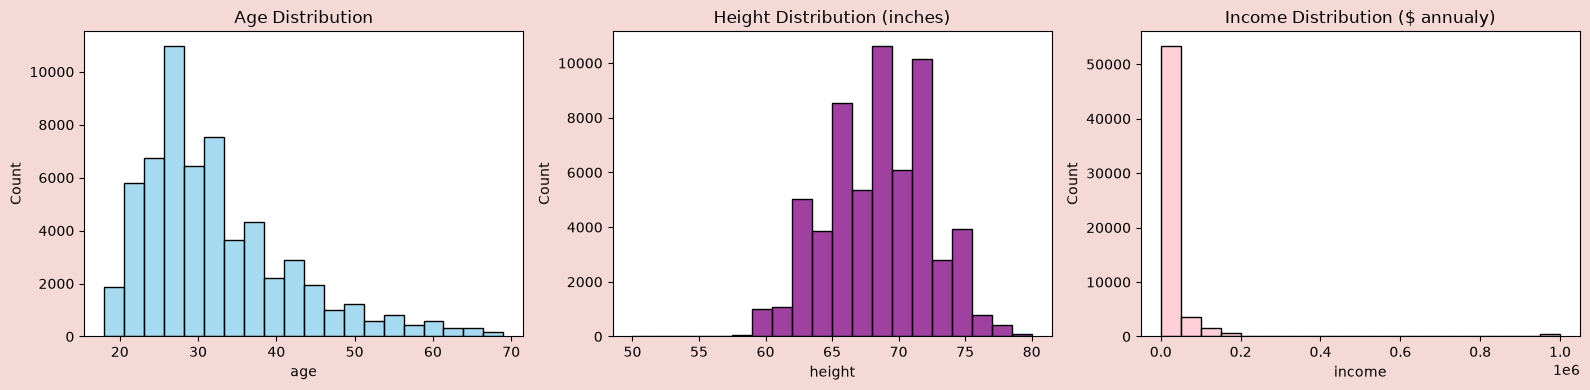

In [42]:
# Visualising the adjusted distributions of age, height and income 
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(profiles_features['age'], bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Age Distribution')

sns.histplot(profiles_features['height'], bins=20, color='purple', ax=ax[1])
ax[1].set_title('Height Distribution (inches)')

sns.histplot(profiles_features['income'], bins=20, color='pink', ax=ax[2])
ax[2].set_title('Income Distribution ($ annualy)')

plt.tight_layout()
plt.savefig('adjageheightincomehist.png', bbox_inches='tight')
plt.show()
plt.close()

Moving on to the categorical columns, we will explore the distributions of each. First we will look at the unique values in each. Then we will visualise the distributions.

In [55]:
# Unique values in each categorical column
categorical_cols = profiles_features.select_dtypes(include=['object','string']).columns
categorical_cols = categorical_cols.drop('last_online')

[print(f'{col} column: \n', profiles_features[col].unique(),'\n') for col in categorical_cols]

body_type column: 
 <StringArray>
['a little extra',        'average',           'thin',       'athletic',
            'fit',              nan,         'skinny',          'curvy',
   'full figured',         'jacked', 'rather not say',        'used up',
     'overweight']
Length: 13, dtype: str 

diet column: 
 <StringArray>
[  'strictly anything',        'mostly other',            'anything',
          'vegetarian',                   nan,     'mostly anything',
   'mostly vegetarian',      'strictly vegan', 'strictly vegetarian',
        'mostly vegan',      'strictly other',        'mostly halal',
               'other',               'vegan',       'mostly kosher',
      'strictly halal',               'halal',     'strictly kosher',
              'kosher']
Length: 19, dtype: str 

drinks column: 
 <StringArray>
['socially', 'often', 'not at all', 'rarely', nan, 'very often',
 'desperately']
Length: 7, dtype: str 

drugs column: 
 <StringArray>
['never', 'sometimes', nan, 'often']
Le

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

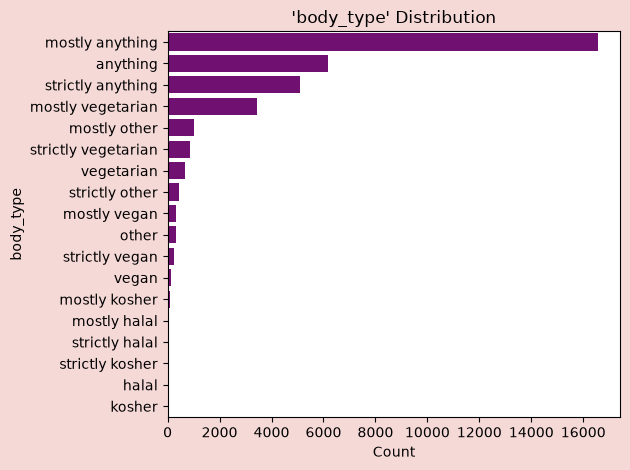

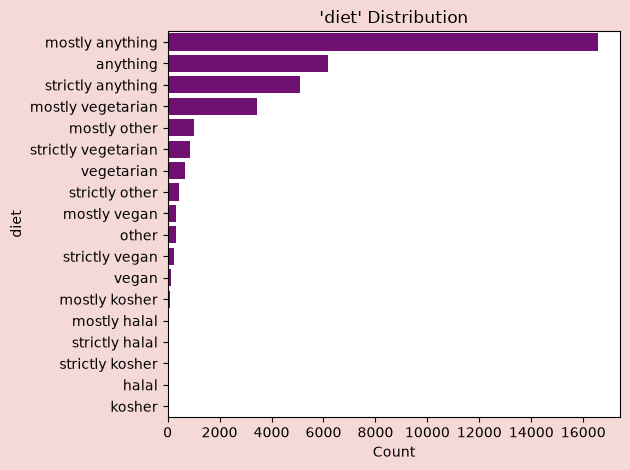

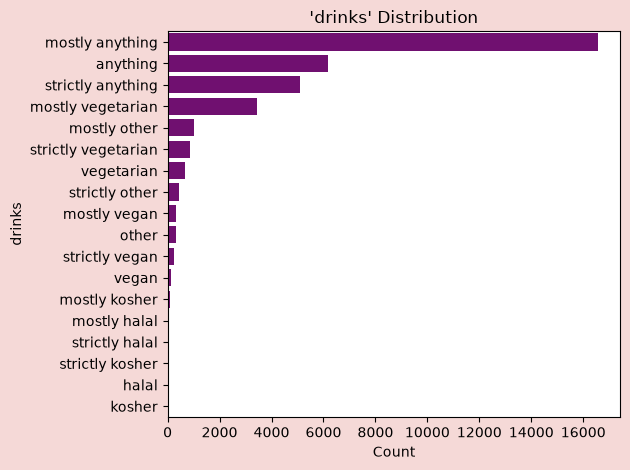

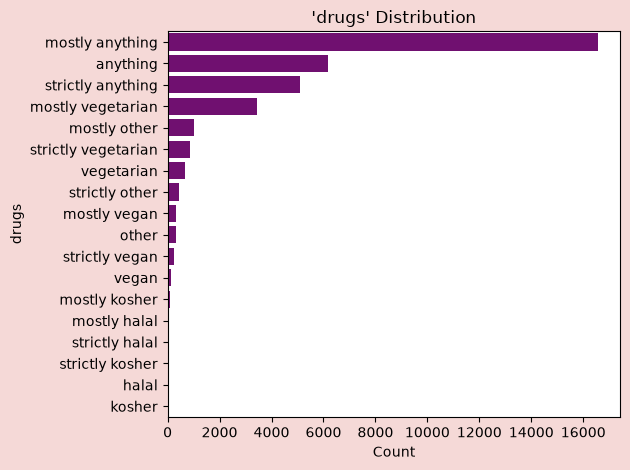

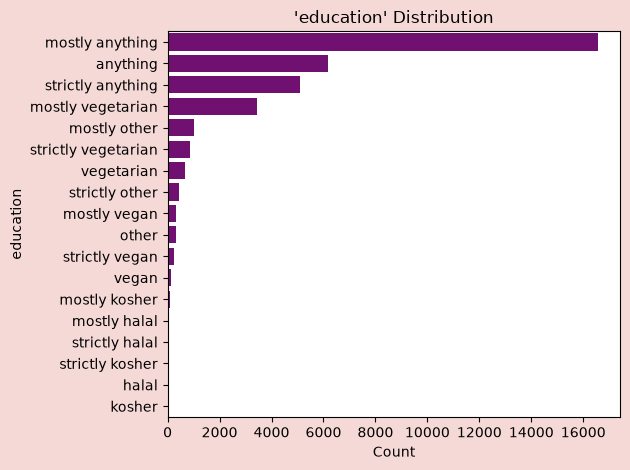

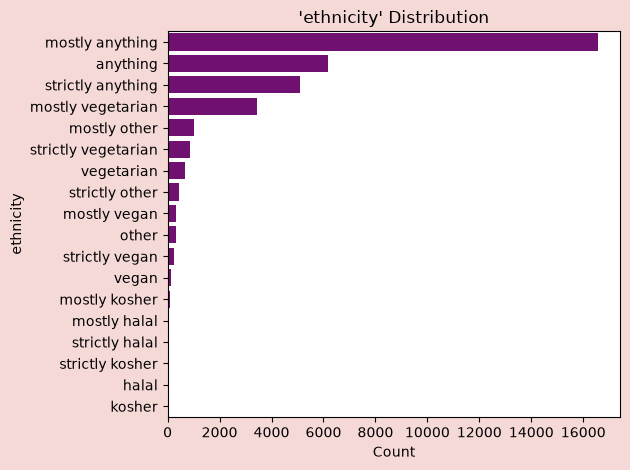

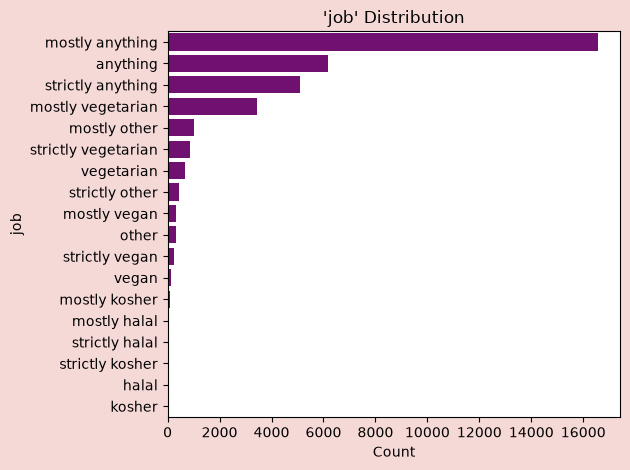

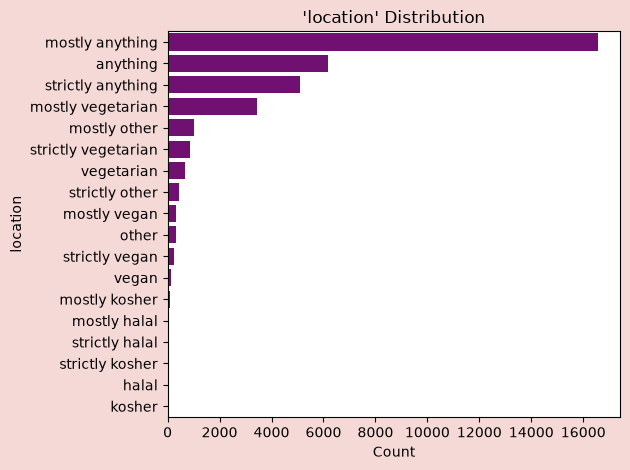

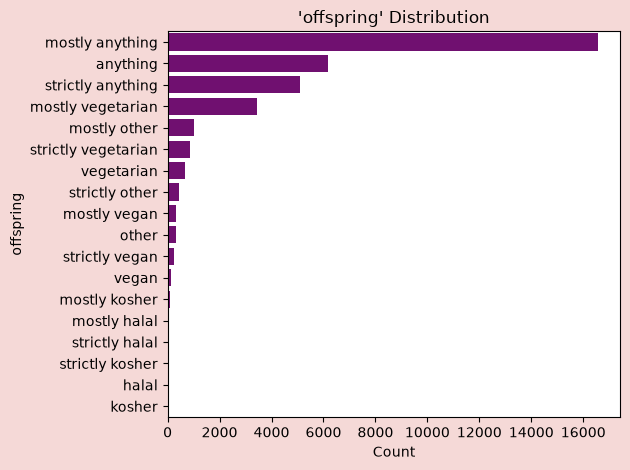

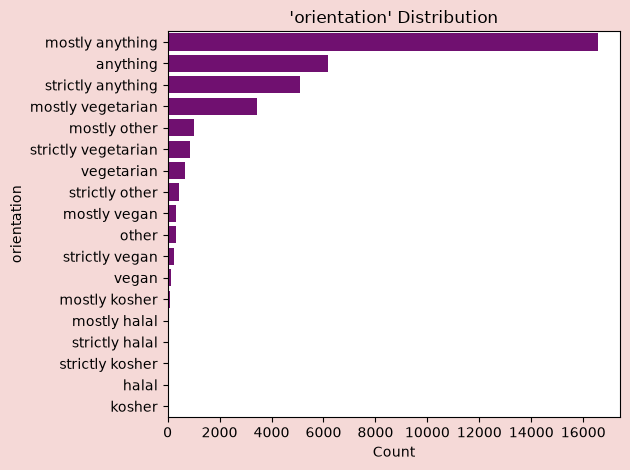

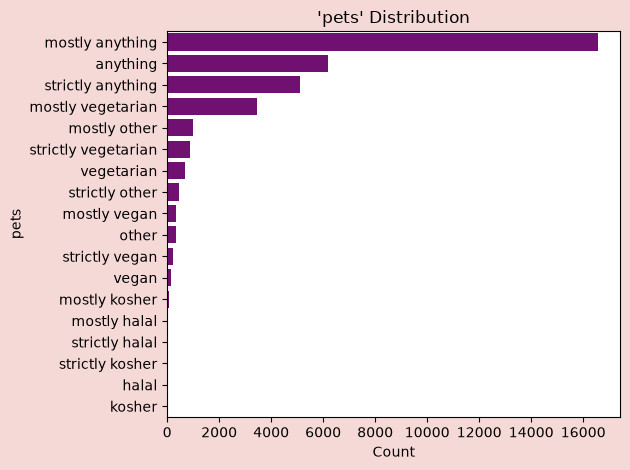

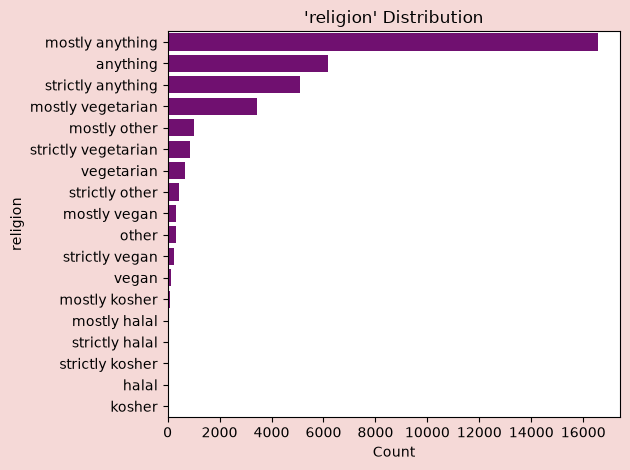

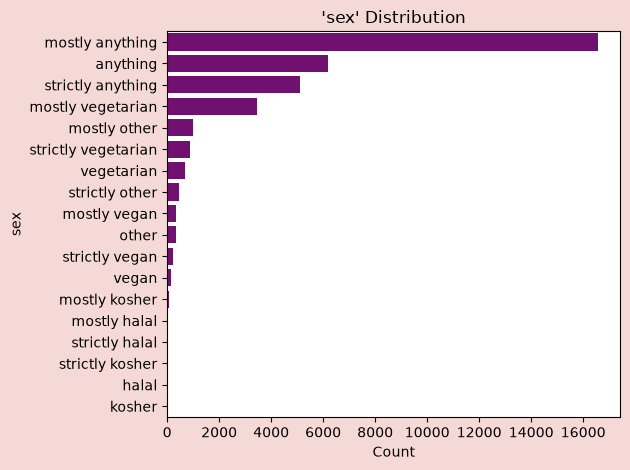

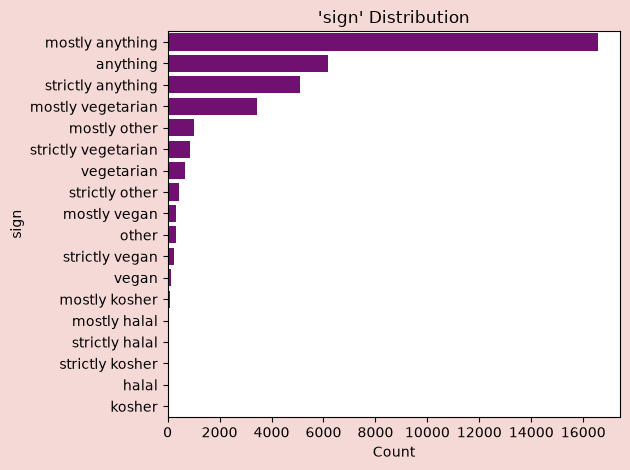

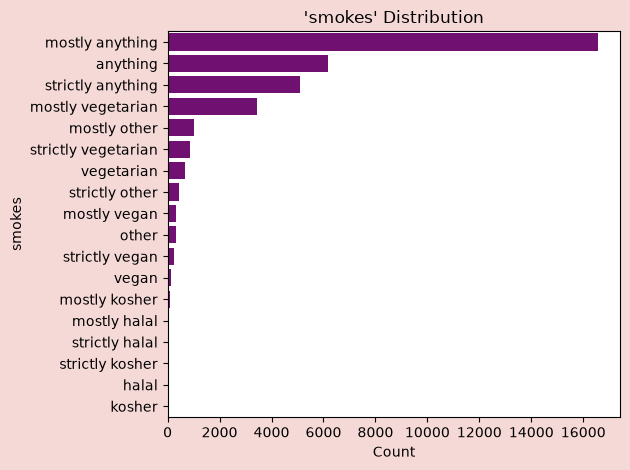

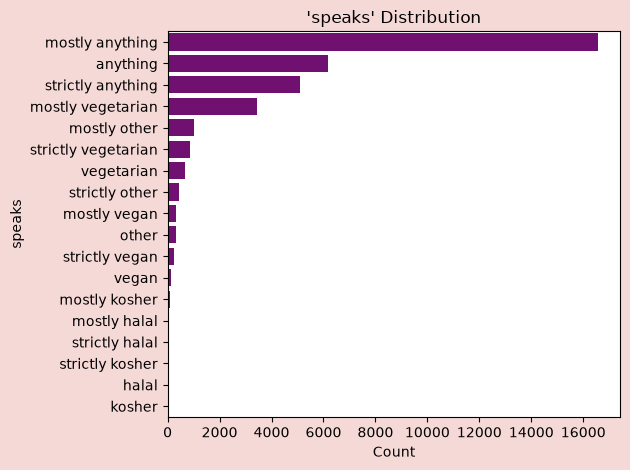

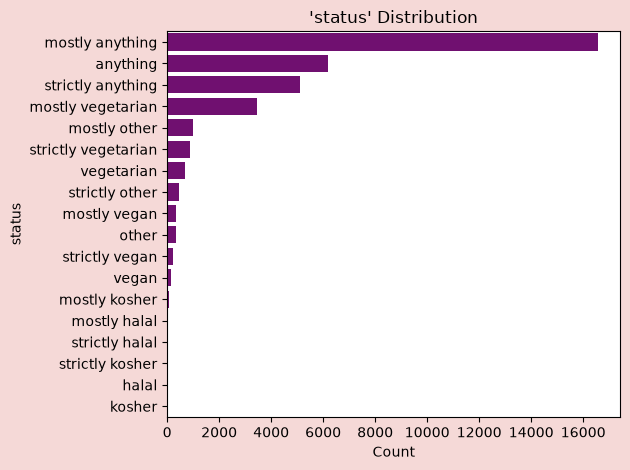

In [63]:
# Plot categorical columns using countplots

for col in categorical_cols:
    sns.countplot(data=profiles, y='diet', order=profiles['diet'].value_counts().index, color='purple')
    plt.title(f'\'{col}\' Distribution')
    plt.xlabel('Count')
    plt.ylabel(f'{col}')
    plt.tight_layout()
    plt.savefig(f'{col}counts.png', bbox_inches='tight')
    plt.show()
    plt.close()

We can see that some columns, such as `diet`, `religion` and `sign` can be simplified to main diet choice, religion choice and zodiac sign respectively, to make our visualisations easier to understand. We will do this with all of the columns that can be summarised in the next step.

In [60]:
# Save main diet choice
profiles_features['diet_cleaned'] = profiles_features['diet'].str.split().str[-1]

# Save main religion choice
profiles_features['religion_cleaned'] = profiles_features['religion'].str.split().str[0]

# Save main sign choice
profiles_features['sign_cleaned'] = profiles_features['sign'].str.split().str[0]

## **Section C:** Data Cleaning and Transformation

Our next step will be to clean and preprocess the data for model training. We will remove rows with null values and simplify some of the categories where needed. We will also encode and standardise the training data after splitting it into testing and training groups.

## **Section D:** Machine Learning Application

### Conclusion